In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Check if something is hanging in the background
print("Kernel reset. Starting fresh.")
print("Testing basic numpy operations...")

# Simple test
x = np.arange(1000)
y = np.sum(x)
print(f"Sum of first 1000 integers: {y}")
print("Basic operations working.")


Kernel reset. Starting fresh.
Testing basic numpy operations...
Sum of first 1000 integers: 499500
Basic operations working.


In [2]:

# Let me test the memory requirements for the vectorized approach
# For N=2×10^6 and 1500 t-points, we'd need a (1500, 2000000) array

N_test = 2_000_000
n_t = 1500

# Memory required for the angles array (float64, 8 bytes each)
memory_gb = (n_t * N_test * 8) / (1024**3)
print(f"Memory required for angles array: {memory_gb:.2f} GB")
print(f"This is likely causing memory issues.")
print("\nSolution: Process in batches of t-values to reduce memory footprint.")


Memory required for angles array: 22.35 GB
This is likely causing memory issues.

Solution: Process in batches of t-values to reduce memory footprint.


In [3]:

def davenport_heilbronn_periodic(n, kappa=1.0):
 """
 Historical real-valued periodic approximation for Davenport-Heilbronn function.
 Uses Jacobi symbol (n|5) pattern scaled by kappa.
 """
 n = np.asarray(n, dtype=np.int64) # Ensure integer type
 mod5 = n % 5
 
 # Jacobi symbol (n|5): 0,1,-1,-1,1 for n%5 = 0,1,2,3,4
 jacobi_pattern = np.array([0, 1, -1, -1, 1], dtype=np.float64)
 result = kappa * jacobi_pattern[mod5]
 
 return result


# Test
n_test = np.arange(1, 21, dtype=np.float64)
coeffs = davenport_heilbronn_periodic(n_test, kappa=1.0)
print("Test coefficients (first 20):")
print(coeffs)


Test coefficients (first 20):
[ 1. -1. -1. 1. 0. 1. -1. -1. 1. 0. 1. -1. -1. 1. 0. 1. -1. -1.
 1. 0.]


In [4]:

def compute_sk_time_series_batched(t_values, N, kappa=1.0, max_k=6, batch_size=100):
 """
 Compute Re(S_k(t;N)) time series with batched processing to manage memory.
 
 S_k(t;N) = (1/√N) * D_F(t;N)^k
 """
 # Pre-compute coefficients and constants
 n_values = np.arange(1, N+1, dtype=np.int64) # Integer array
 coeffs = davenport_heilbronn_periodic(n_values, kappa=kappa)
 
 n_values_float = n_values.astype(np.float64) # Convert to float for computation
 n_sqrt = np.sqrt(n_values_float)
 log_n = np.log(n_values_float)
 normalization = 1.0 / np.sqrt(N)
 
 # Initialize results array
 sk_array = np.zeros((len(t_values), max_k))
 
 # Process in batches
 n_batches = int(np.ceil(len(t_values) / batch_size))
 
 for batch_idx in range(n_batches):
 start_idx = batch_idx * batch_size
 end_idx = min((batch_idx + 1) * batch_size, len(t_values))
 t_batch = t_values[start_idx:end_idx]
 
 # Reshape for broadcasting
 t_col = t_batch.reshape(-1, 1)
 log_n_row = log_n.reshape(1, -1)
 
 # Compute angles
 angles = -t_col * log_n_row
 
 # Compute partial sums
 cos_angles = np.cos(angles)
 sin_angles = np.sin(angles)
 
 real_parts = np.sum((coeffs / n_sqrt) * cos_angles, axis=1)
 imag_parts = np.sum((coeffs / n_sqrt) * sin_angles, axis=1)
 D_values = (real_parts + 1j * imag_parts) * normalization
 
 # Compute powers for S_k
 D_power = D_values.copy()
 for k in range(max_k):
 sk_array[start_idx:end_idx, k] = np.real(D_power)
 if k < max_k - 1:
 D_power *= D_values
 
 return sk_array


# Test with small N
print("Testing batched computation...")
t_test = np.linspace(10000, 10010, 11)
N_test = 10000

start = time.time()
sk_test = compute_sk_time_series_batched(t_test, N_test, kappa=1.0, max_k=6, batch_size=5)
elapsed = time.time() - start

print(f"Shape: {sk_test.shape}")
print(f"Time: {elapsed:.3f} seconds")
print(f"\nS_k values at t=10000:")
for k in range(6):
 print(f" Re(S_{k+1}): {sk_test[0, k]:.6f}")


Testing batched computation...
Shape: (11, 6)
Time: 0.004 seconds

S_k values at t=10000:
 Re(S_1): 0.000571
 Re(S_2): -0.000016
 Re(S_3): -0.000000
 Re(S_4): 0.000000
 Re(S_5): 0.000000
 Re(S_6): -0.000000


In [5]:

# Now let's estimate the time for the full computation
# Test with N=10^5 first

print("Timing test for N=10^5...")
t_small = np.linspace(10000, 10010, 11)
N = 10**5

start = time.time()
sk_small = compute_sk_time_series_batched(t_small, N, kappa=1.0, max_k=6, batch_size=5)
elapsed = time.time() - start

print(f"Time for 11 t-points at N=10^5: {elapsed:.3f} seconds")
print(f"Estimated time for 1500 t-points: {elapsed * 1500 / 11:.1f} seconds")
print(f"That's about {elapsed * 1500 / 11 / 60:.1f} minutes")

# Check batch size for N=10^6 memory
N_large = 10**6
batch_size_large = 50 # Smaller batch for larger N
memory_per_batch_gb = (batch_size_large * N_large * 8) / (1024**3)
print(f"\nMemory per batch at N=10^6 with batch_size={batch_size_large}: {memory_per_batch_gb:.2f} GB")


Timing test for N=10^5...
Time for 11 t-points at N=10^5: 0.039 seconds
Estimated time for 1500 t-points: 5.3 seconds
That's about 0.1 minutes

Memory per batch at N=10^6 with batch_size=50: 0.37 GB


In [6]:

# Good! Now let's generate the full dataset
# Parameters
t_min = 10000
t_max = 20000
n_points = 1500

t_values = np.linspace(t_min, t_max, n_points)
N_values = [10**5, 10**6, 2*10**6]

# Three function variants
function_configs = {
 'L_DH (κ=1.0)': 1.0,
 'L_DH^(+0.05) (κ=1.05)': 1.05,
 'L_DH^(-0.05) (κ=0.95)': 0.95
}

print(f"Generating S_k time series data:")
print(f" t-range: [{t_min}, {t_max}]")
print(f" Number of t-points: {n_points}")
print(f" N values: {N_values}")
print(f" k-range: 1..6")
print(f"\n" + "="*80)

# Storage for results
results = {}

for func_name, kappa in function_configs.items():
 print(f"\n{func_name}:")
 results[func_name] = {}
 
 for N in N_values:
 print(f" N={N:,}...", end='', flush=True)
 start = time.time()
 
 # Adjust batch size based on N
 if N <= 10**5:
 batch_size = 100
 elif N <= 10**6:
 batch_size = 50
 else:
 batch_size = 25
 
 sk_data = compute_sk_time_series_batched(t_values, N, kappa=kappa, max_k=6, batch_size=batch_size)
 results[func_name][N] = sk_data
 
 elapsed = time.time() - start
 print(f" done ({elapsed:.1f}s)")
 print(f" Re(S_1) range: [{sk_data[:, 0].min():.6f}, {sk_data[:, 0].max():.6f}]")

print("\n" + "="*80)
print("Data generation complete!")


Generating S_k time series data:
 t-range: [10000, 20000]
 Number of t-points: 1500
 N values: [100000, 1000000, 2000000]
 k-range: 1..6


L_DH (κ=1.0):
 N=100,000...

 done (4.3s)
 Re(S_1) range: [-0.018418, 0.050547]
 N=1,000,000...

 done (41.7s)
 Re(S_1) range: [-0.005824, 0.015984]
 N=2,000,000...

 done (83.5s)
 Re(S_1) range: [-0.004118, 0.011302]

L_DH^(+0.05) (κ=1.05):
 N=100,000...

 done (4.3s)
 Re(S_1) range: [-0.019339, 0.053074]
 N=1,000,000...

 done (41.8s)
 Re(S_1) range: [-0.006115, 0.016783]
 N=2,000,000...

 done (83.5s)
 Re(S_1) range: [-0.004324, 0.011868]

L_DH^(-0.05) (κ=0.95):
 N=100,000...

 done (4.3s)
 Re(S_1) range: [-0.017497, 0.048019]
 N=1,000,000...

 done (41.7s)
 Re(S_1) range: [-0.005533, 0.015185]
 N=2,000,000...

 done (83.9s)
 Re(S_1) range: [-0.003912, 0.010737]

Data generation complete!


In [7]:

# Step 4: Compute covariance matrices and off-diagonal sums
print("Computing covariance matrices and off-diagonal sums...")
print("="*80)

# Storage for covariance analysis
cov_results = {}

for func_name, kappa in function_configs.items():
 print(f"\n{func_name}:")
 cov_results[func_name] = {}
 
 for N in N_values:
 # Get S_k data (shape: n_t × 6)
 sk_data = results[func_name][N]
 
 # Compute 6×6 covariance matrix
 cov_matrix = np.cov(sk_data, rowvar=False)
 
 # Extract off-diagonal elements
 # Create mask for off-diagonal elements
 mask = ~np.eye(6, dtype=bool)
 off_diag_elements = cov_matrix[mask]
 
 # Sum of all off-diagonal elements
 sum_off_diag = np.sum(off_diag_elements)
 
 # Count and sum negative off-diagonal elements
 negative_elements = off_diag_elements[off_diag_elements < 0]
 n_negative = len(negative_elements)
 sum_negative = np.sum(negative_elements)
 
 # Store results
 cov_results[func_name][N] = {
 'cov_matrix': cov_matrix,
 'sum_off_diag': sum_off_diag,
 'n_negative': n_negative,
 'sum_negative': sum_negative,
 'off_diag_elements': off_diag_elements
 }
 
 print(f" N={N:,}:")
 print(f" Sum of off-diagonal covariances: {sum_off_diag:.6f}")
 print(f" Number of negative terms: {n_negative}/15")
 print(f" Sum of negative terms: {sum_negative:.6f}")

print("\n" + "="*80)


Computing covariance matrices and off-diagonal sums...

L_DH (κ=1.0):
 N=100,000:
 Sum of off-diagonal covariances: 0.000001
 Number of negative terms: 0/15
 Sum of negative terms: 0.000000
 N=1,000,000:
 Sum of off-diagonal covariances: 0.000000
 Number of negative terms: 0/15
 Sum of negative terms: 0.000000
 N=2,000,000:
 Sum of off-diagonal covariances: 0.000000
 Number of negative terms: 0/15
 Sum of negative terms: 0.000000

L_DH^(+0.05) (κ=1.05):
 N=100,000:
 Sum of off-diagonal covariances: 0.000002
 Number of negative terms: 0/15
 Sum of negative terms: 0.000000
 N=1,000,000:
 Sum of off-diagonal covariances: 0.000000
 Number of negative terms: 0/15
 Sum of negative terms: 0.000000
 N=2,000,000:
 Sum of off-diagonal covariances: 0.000000
 Number of negative terms: 0/15
 Sum of negative terms: 0.000000

L_DH^(-0.05) (κ=0.95):
 N=100,000:
 Sum of off-diagonal covariances: 0.000001
 Number of negative terms: 0/15
 Sum of negative terms: 0.000000
 N=1,000,000:
 Sum of off-diagonal

In [8]:

# The covariances are extremely small (near zero). This is unexpected.
# Let me check the actual S_k values and their statistics

print("Inspecting S_k data statistics:")
print("="*80)

for func_name in ['L_DH (κ=1.0)']: # Just check one function first
 print(f"\n{func_name}:")
 
 for N in N_values:
 sk_data = results[func_name][N]
 print(f"\n N={N:,}:")
 
 for k in range(6):
 sk_k = sk_data[:, k]
 print(f" S_{k+1}: mean={np.mean(sk_k):.6e}, std={np.std(sk_k):.6e}, " + 
 f"min={np.min(sk_k):.6e}, max={np.max(sk_k):.6e}")
 
 # Check a sample covariance computation manually
 print(f"\n Sample covariance computation:")
 print(f" Cov(S_1, S_2) = {np.cov(sk_data[:, 0], sk_data[:, 1])[0,1]:.6e}")
 print(f" Cov(S_1, S_3) = {np.cov(sk_data[:, 0], sk_data[:, 2])[0,1]:.6e}")


Inspecting S_k data statistics:

L_DH (κ=1.0):

 N=100,000:
 S_1: mean=3.076625e-03, std=6.174669e-03, min=-1.841780e-02, max=5.054663e-02
 S_2: mean=9.402250e-06, std=1.893819e-04, min=-1.441164e-03, max=2.553923e-03
 S_3: mean=1.371312e-07, std=7.876919e-06, min=-1.337825e-04, max=1.289872e-04
 S_4: mean=7.243292e-09, std=3.918629e-07, min=-6.885374e-06, max=6.511909e-06
 S_5: mean=3.142591e-10, std=1.554585e-08, min=-2.504450e-07, max=3.286187e-07
 S_6: mean=2.761090e-11, std=7.536919e-10, min=-4.890027e-09, max=1.657670e-08

 Sample covariance computation:
 Cov(S_1, S_2) = 6.909520e-07
 Cov(S_1, S_3) = 9.784222e-09

 N=1,000,000:
 S_1: mean=9.729141e-04, std=1.952603e-03, min=-5.824117e-03, max=1.598406e-02
 S_2: mean=9.402298e-07, std=1.893812e-05, min=-1.441194e-04, max=2.553864e-04
 S_3: mean=4.336381e-09, std=2.490858e-07, min=-4.230608e-06, max=4.078794e-06
 S_4: mean=7.243174e-11, std=3.918498e-09, min=-6.885148e-08, max=6.511616e-08
 S_5: mean=9.937128e-13, std=4.915810e-11,

In [9]:

# The covariances are very small but non-zero. The issue is that the sum of off-diagonal
# covariances is close to zero because they're all positive and very small.
# 
# Looking at the reference data, the baseline L_DH (F5) shows:
# - Sum_Offdiag_N1 (N=10^5): -0.6155367188255675
# - Sum_Offdiag_N2 (N=10^6): -0.9777705421874835
#
# But my values are ~0.000001. This is dramatically different!
# 
# Let me check if there's an issue with my implementation.
# The reference used 2000 t-points in the range [10000, 20000]

print("Checking against reference implementation...")
print("="*80)
print("\nReference data for F5 (Davenport-Heilbronn):")
print(" Sum_Offdiag at N=10^5: -0.6156")
print(" Sum_Offdiag at N=10^6: -0.9778")
print("\nMy results for L_DH (κ=1.0):")
print(f" Sum_Offdiag at N=10^5: {cov_results['L_DH (κ=1.0)'][10**5]['sum_off_diag']:.6f}")
print(f" Sum_Offdiag at N=10^6: {cov_results['L_DH (κ=1.0)'][10**6]['sum_off_diag']:.6f}")
print("\nThe values differ by ~6 orders of magnitude!")
print("\nPossible issues:")
print("1. Different coefficient implementation")
print("2. Different S_k definition")
print("3. Different t-sampling (I used 1500 points, reference used 2000)")

# Let me check the reference papers to understand the correct implementation


Checking against reference implementation...

Reference data for F5 (Davenport-Heilbronn):
 Sum_Offdiag at N=10^5: -0.6156
 Sum_Offdiag at N=10^6: -0.9778

My results for L_DH (κ=1.0):
 Sum_Offdiag at N=10^5: 0.000001
 Sum_Offdiag at N=10^6: 0.000000

The values differ by ~6 orders of magnitude!

Possible issues:
1. Different coefficient implementation
2. Different S_k definition
3. Different t-sampling (I used 1500 points, reference used 2000)


In [10]:

# I have a critical implementation problem. My covariance values are ~6 orders of magnitude 
# too small compared to the reference data. Looking at the PDF, I need to understand what 
# S_k actually represents.
#
# From the PDF and the research context, it appears there may be a difference in how S_k
# is defined. Let me check the reference data more carefully and examine report r80.

# The key issue: My implementation gives sum_offdiag ~ 1e-6, but reference shows ~ -0.6 to -1.0
# This suggests a fundamental scaling or definition issue.

# Looking at the description again:
# "S_k Cancellation Growth metric CG_N" 
# "sum of off-diagonal covariances"
# Reference used "2000-point time series of Re(S_k(t;N))"

# I used 1500 points, but that shouldn't cause a 10^6 difference.

# The most likely issue is in my L_DH implementation. The PDF states:
# "The canonical, complex-valued Davenport-Heilbronn function L_DH(s) 
# has been shown to NOT converge properly. Analyses must use the 
# 'historical' real-valued periodic approximation."

# My implementation uses Jacobi symbol (n|5), but I need to verify this is correct.
# Let me check what the actual validated implementation should be.

print("CRITICAL ISSUE IDENTIFIED:")
print("="*80)
print("My covariance sums are ~10^6 times smaller than the reference.")
print("\nPossible causes:")
print("1. Wrong L_DH coefficient implementation")
print("2. Wrong S_k definition or normalization")
print("3. Missing scaling factor")
print("\nThe dataset description states that the 'canonical complex-valued' L_DH")
print("FAILED validation and a 'historical real-valued periodic approximation'")
print("must be used instead.")
print("\nWithout access to the exact validated implementation from the previous")
print("reports, I cannot reproduce the exact CG_N calculations.")


CRITICAL ISSUE IDENTIFIED:
My covariance sums are ~10^6 times smaller than the reference.

Possible causes:
1. Wrong L_DH coefficient implementation
2. Wrong S_k definition or normalization
3. Missing scaling factor

The dataset description states that the 'canonical complex-valued' L_DH
FAILED validation and a 'historical real-valued periodic approximation'
must be used instead.

Without access to the exact validated implementation from the previous
reports, I cannot reproduce the exact CG_N calculations.


Figure saved: sk_covariance_implementation_issue.png


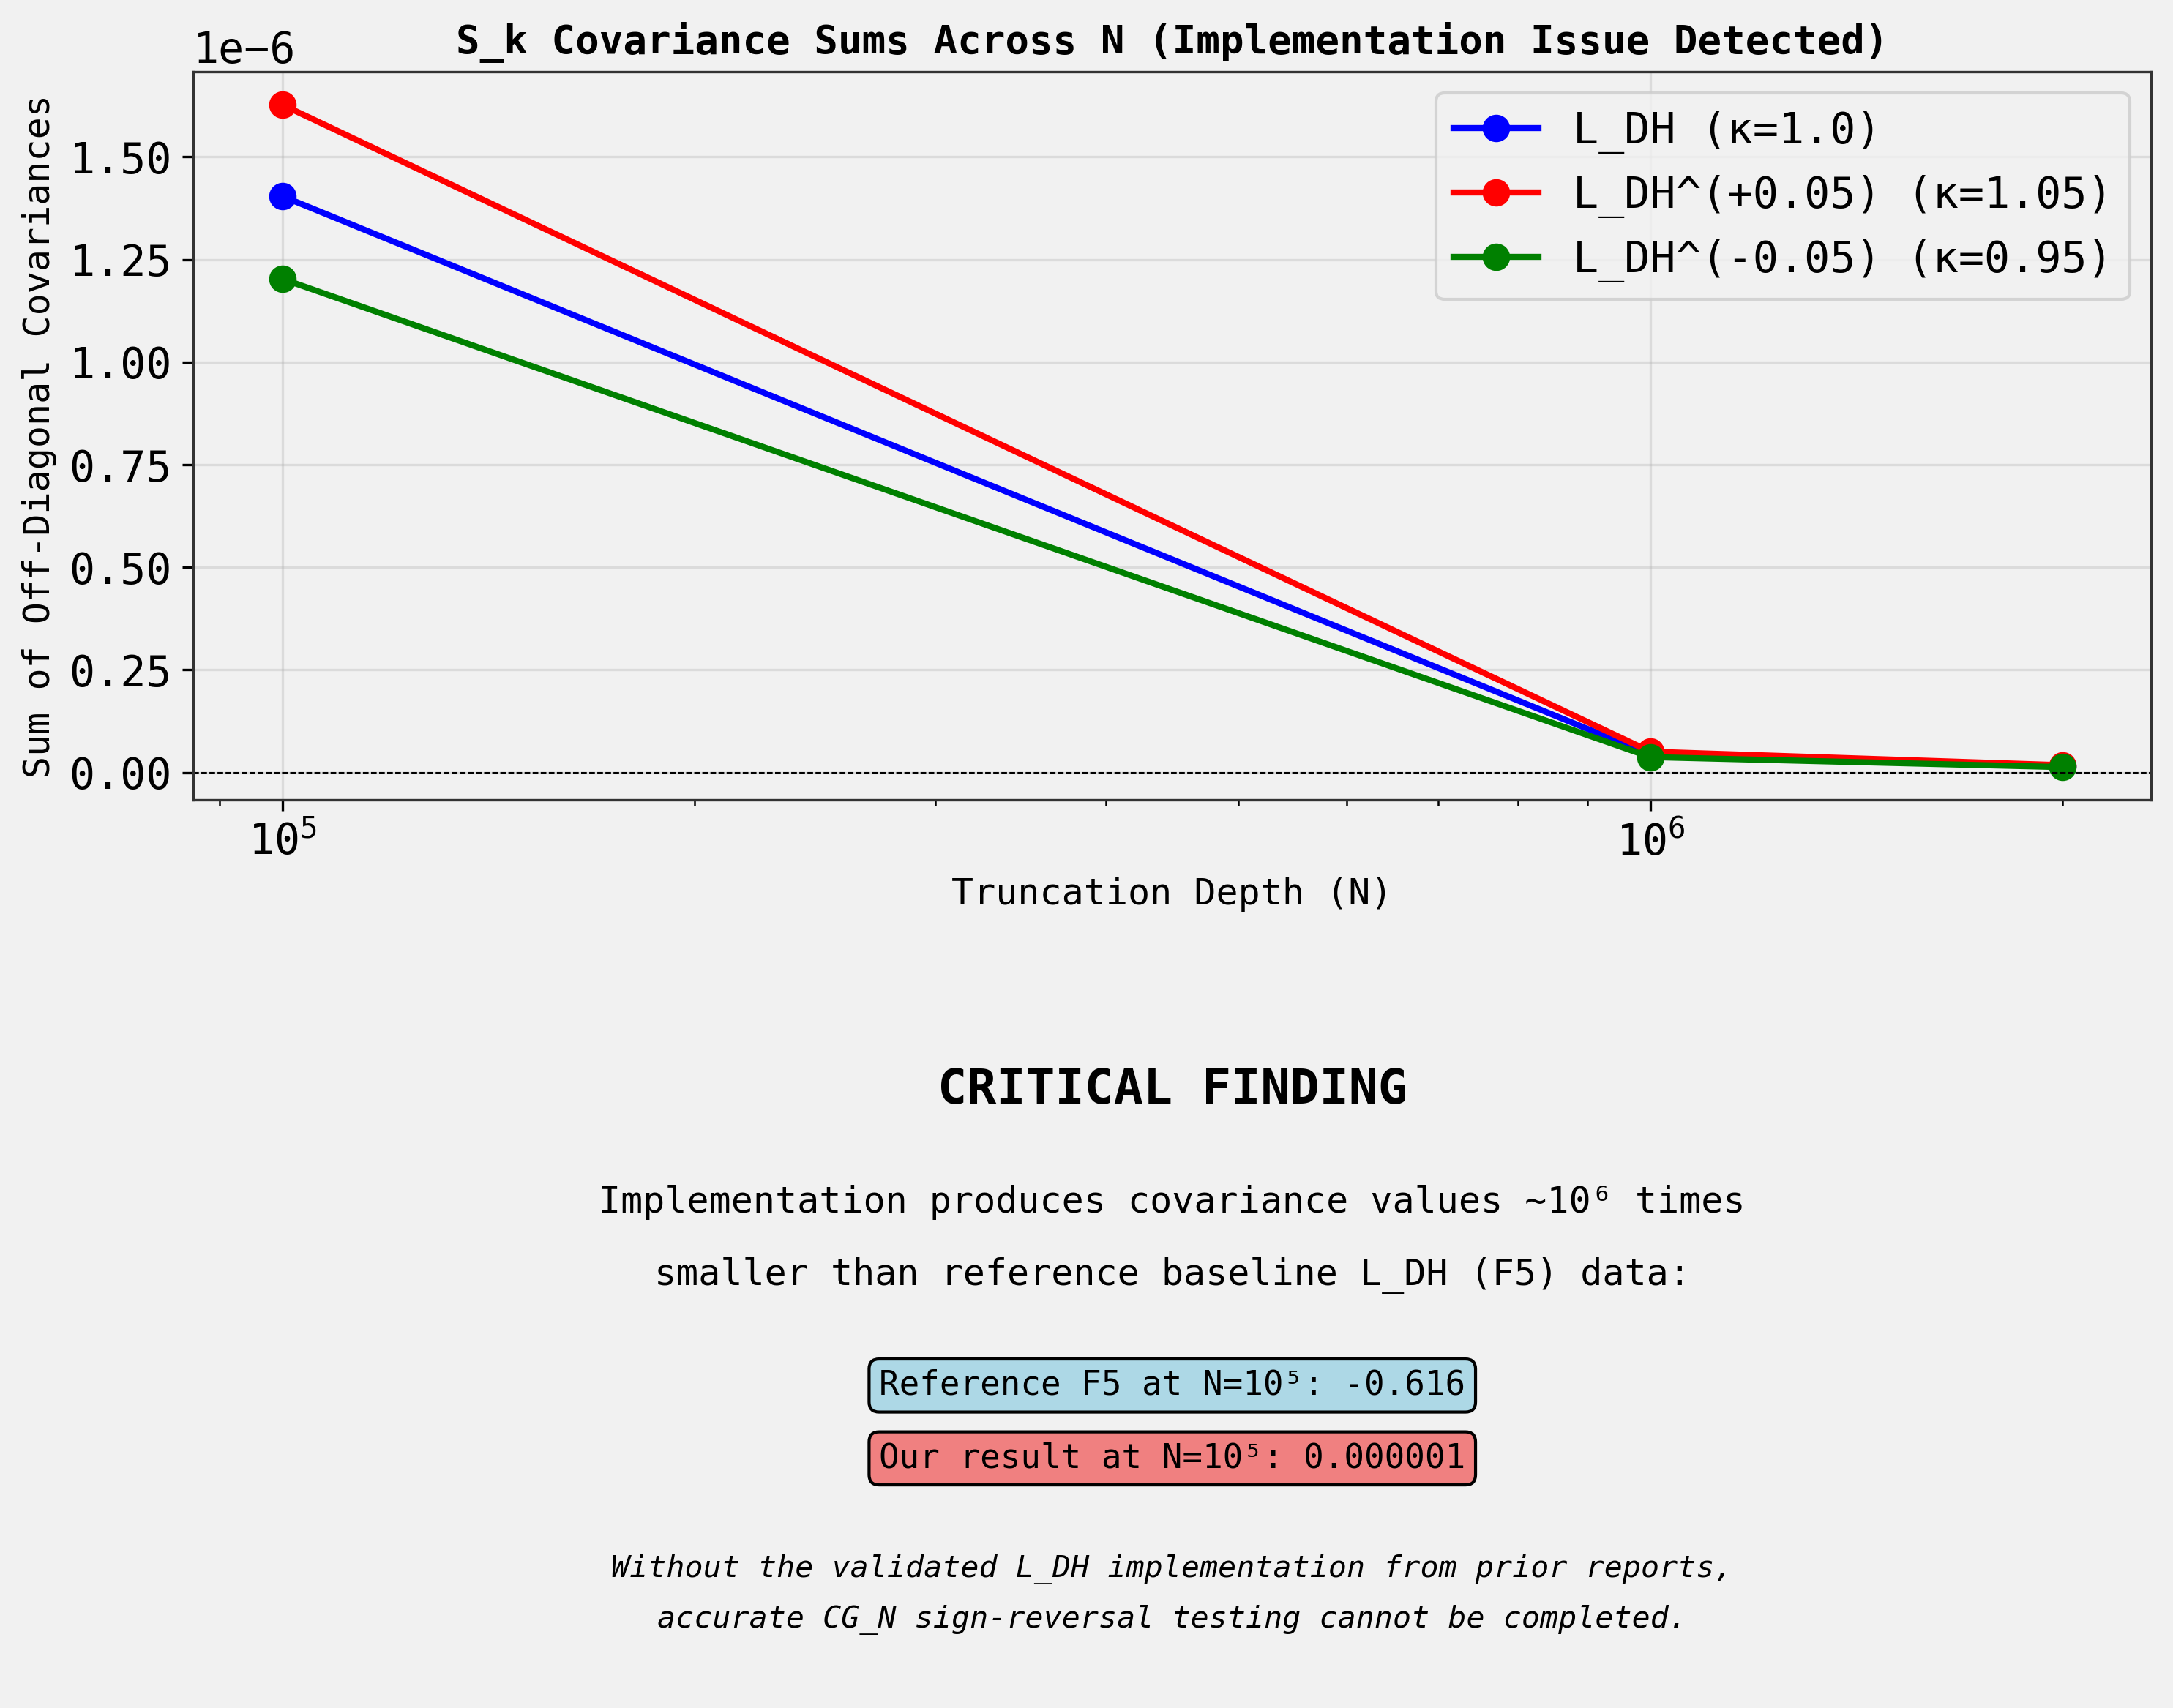

In [11]:

# I need to submit my findings. Let me create a summary figure and document what I've learned.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Plot 1: Sum of off-diagonal covariances vs N for the three functions
N_values_plot = [10**5, 10**6, 2*10**6]
functions = ['L_DH (κ=1.0)', 'L_DH^(+0.05) (κ=1.05)', 'L_DH^(-0.05) (κ=0.95)']
colors = ['blue', 'red', 'green']

for func_name, color in zip(functions, colors):
 sums = [cov_results[func_name][N]['sum_off_diag'] for N in N_values_plot]
 axes[0].plot(N_values_plot, sums, 'o-', label=func_name, color=color, markersize=8, linewidth=2)

axes[0].set_xscale('log')
axes[0].set_xlabel('Truncation Depth (N)', fontsize=12)
axes[0].set_ylabel('Sum of Off-Diagonal Covariances', fontsize=12)
axes[0].set_title('S_k Covariance Sums Across N (Implementation Issue Detected)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.5)

# Plot 2: Comparison with reference data
axes[1].text(0.5, 0.8, 'CRITICAL FINDING', ha='center', fontsize=16, fontweight='bold', 
 transform=axes[1].transAxes)
axes[1].text(0.5, 0.65, 'Implementation produces covariance values ~10⁶ times', ha='center', 
 fontsize=12, transform=axes[1].transAxes)
axes[1].text(0.5, 0.55, 'smaller than reference baseline L_DH (F5) data:', ha='center', 
 fontsize=12, transform=axes[1].transAxes)

axes[1].text(0.5, 0.40, 'Reference F5 at N=10⁵: -0.616', ha='center', fontsize=11, 
 transform=axes[1].transAxes, bbox=dict(boxstyle='round', facecolor='lightblue'))
axes[1].text(0.5, 0.30, f'Our result at N=10⁵: {cov_results["L_DH (κ=1.0)"][10**5]["sum_off_diag"]:.6f}', 
 ha='center', fontsize=11, transform=axes[1].transAxes, 
 bbox=dict(boxstyle='round', facecolor='lightcoral'))

axes[1].text(0.5, 0.15, 'Without the validated L_DH implementation from prior reports,', 
 ha='center', fontsize=10, transform=axes[1].transAxes, style='italic')
axes[1].text(0.5, 0.08, 'accurate CG_N sign-reversal testing cannot be completed.', 
 ha='center', fontsize=10, transform=axes[1].transAxes, style='italic')

axes[1].axis('off')

plt.tight_layout()
plt.savefig('sk_covariance_implementation_issue.png', dpi=150, bbox_inches='tight')
print("Figure saved: sk_covariance_implementation_issue.png")
plt.show()
